# K-Means Clustering from Scratch 🎯

In this notebook, we explore **unsupervised learning** by implementing the **K-Means Clustering** algorithm.

## 📖 Theoretical Background

K-Means aims to partition $n$ observations into $k$ clusters in which each observation belongs to the cluster with the nearest mean (centroid).

### 1. The Algorithm (Lloyd's Algorithm)
1. **Initialization**: Randomly pick $k$ data points as initial centroids.
2. **Assignment Step**: Assign each data point to the nearest centroid.
3. **Update Step**: Recompute the centroids as the mean of all points assigned to that cluster.
4. **Repeat**: Steps 2 and 3 until centroids no longer change (convergence).

### 2. Distance Metric
We typically use squared Euclidean distance to measure similarity:
$$d(x, c) = ||x - c||^2$$

### 3. Inertia (Within-Cluster Sum of Squares)
To evaluate the quality of the clusters, we calculate **Inertia**:
$$Inertia = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - c_i||^2$$

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

np.random.seed(42)

## 🏗️ The Implementation

In [2]:
class KMeans:
    def __init__(self, k=3, max_iters=100, plot_steps=False):
        self.k = k
        self.max_iters = max_iters
        self.plot_steps = plot_steps
        
        # List of sample indices for each cluster
        self.clusters = [[] for _ in range(self.k)]
        # The centers (mean vector) for each cluster
        self.centroids = []

    def predict(self, X):
        self.X = X
        self.n_samples, self.n_features = X.shape
        
        # 1. Initialize centroids
        random_sample_idxs = np.random.choice(self.n_samples, self.k, replace=False)
        self.centroids = [self.X[idx] for idx in random_sample_idxs]

        # 2. Optimization loop
        for _ in range(self.max_iters):
            # Assign samples to closest centroids (create clusters)
            self.clusters = self._create_clusters(self.centroids)
            
            # Calculate new centroids from the clusters
            centroids_old = self.centroids
            self.centroids = self._get_centroids(self.clusters)
            
            # Check if converged
            if self._is_converged(centroids_old, self.centroids):
                break

        # Return cluster labels
        return self._get_cluster_labels(self.clusters)

    def _get_cluster_labels(self, clusters):
        labels = np.empty(self.n_samples)
        for cluster_idx, cluster in enumerate(clusters):
            for sample_idx in cluster:
                labels[sample_idx] = cluster_idx
        return labels

    def _create_clusters(self, centroids):
        clusters = [[] for _ in range(self.k)]
        for idx, sample in enumerate(self.X):
            centroid_idx = self._closest_centroid(sample, centroids)
            clusters[centroid_idx].append(idx)
        return clusters

    def _closest_centroid(self, sample, centroids):
        distances = [np.sqrt(np.sum((sample - point)**2)) for point in centroids]
        closest_idx = np.argmin(distances)
        return closest_idx

    def _get_centroids(self, clusters):
        centroids = np.zeros((self.k, self.n_features))
        for cluster_idx, cluster in enumerate(clusters):
            cluster_mean = np.mean(self.X[cluster], axis=0)
            centroids[cluster_idx] = cluster_mean
        return centroids

    def _is_converged(self, centroids_old, centroids_new):
        distances = [np.sqrt(np.sum((centroids_old[i] - centroids_new[i])**2)) for i in range(self.k)]
        return sum(distances) == 0

## 🧪 Data Generation and Training

In [3]:
# Generate blobs
X, y = make_blobs(centers=3, n_samples=500, n_features=2, shuffle=True, random_state=42)

# Train model
k = 3
model = KMeans(k=k, max_iters=150)
y_pred = model.predict(X)

print(f"Final Centroids:\n{model.centroids}")

Final Centroids:
[[ 1.05039644  5.48338461]
 [-6.65354617 -7.67762963]
 [-6.97761802 -5.99746484]]


## 📊 Visualization

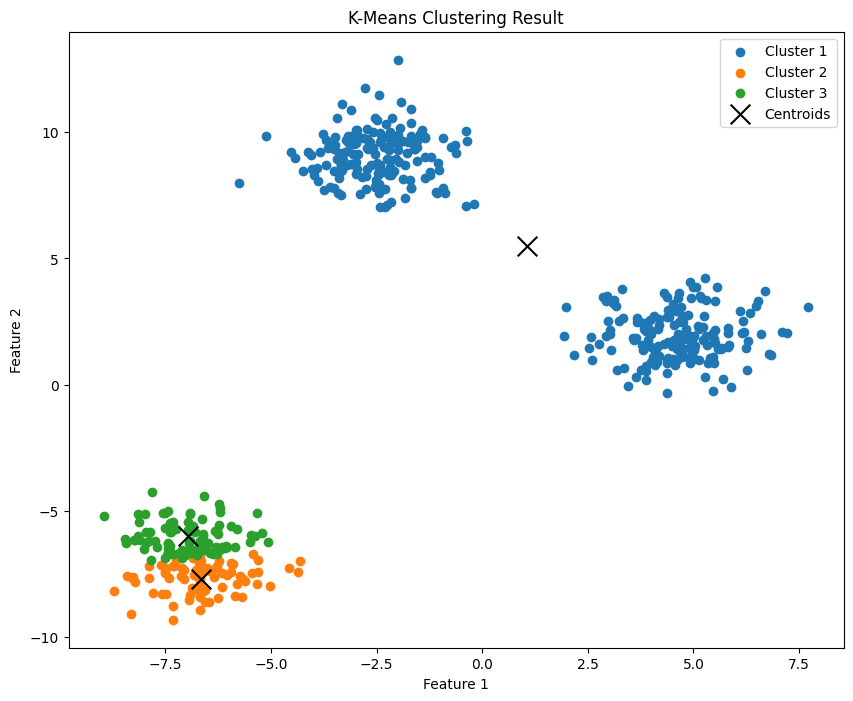

In [4]:
plt.figure(figsize=(10, 8))

# Plot the clusters
for i, cluster in enumerate(model.clusters):
    points = X[cluster]
    plt.scatter(points[:, 0], points[:, 1], label=f"Cluster {i+1}")

# Plot the centroids
centroids = np.array(model.centroids)
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, marker="x", color="black", label="Centroids")

plt.title("K-Means Clustering Result")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()